In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('../../data/gold_policy_clean.csv', parse_dates=['date'])

# ── Constants ─────────────────────────────────────────────────────────────────
DUTY_CUT    = pd.Timestamp('2024-07-24')
POLICY_DATE = pd.Timestamp('2026-05-13')
# Load ITS headline result from shared cache (written by 03_causal.ipynb)
import json as _json
with open('../../data/its_results.json') as _f:
    _cache = _json.load(_f)
ITS_BETA1 = _cache['ITS_BETA1']  # headline from Notebook 03

# ── Prep: Prophet requires ds / y columns ─────────────────────────────────────
# Primary spec: low-duty window only (matches 03_causal.ipynb)
pdata = (df[df['date'] >= DUTY_CUT][['date', 'domestic_premium']]
           .dropna()
           .rename(columns={'date': 'ds', 'domestic_premium': 'y'})
           .reset_index(drop=True))

print(f'Window : {pdata["ds"].min().date()} → {pdata["ds"].max().date()}')
print(f'N      : {len(pdata)}  (pre-hike={( pdata["ds"] < POLICY_DATE).sum()}, post-hike={(pdata["ds"] >= POLICY_DATE).sum()})')
print(f'y range: ₹{pdata["y"].min():,.0f} to ₹{pdata["y"].max():,.0f}')

/Users/olixstudios/Documents/workspace/Projects/gold-policy-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Window : 2024-07-25 → 2026-06-30
N      : 352  (pre-hike=321, post-hike=31)
y range: ₹-6,115 to ₹13,635


In [2]:
# ── Fit Prophet on pre-hike only → project forward as counterfactual ──────────
# (Fitting ON the post-hike data and forcing a changepoint would be circular —
#  training on pre-hike alone gives an independent counterfactual estimate.)
pre_data = pdata[pdata['ds'] < POLICY_DATE].copy()

model = Prophet(
    n_changepoints          = 10,
    changepoint_prior_scale = 0.05,
    seasonality_mode        = 'additive',
    weekly_seasonality      = True,
    yearly_seasonality      = False,   # only ~2yr of data — don't overfit annual
    daily_seasonality       = False,
)
model.fit(pre_data)

# Predict full window so we can compare actual vs counterfactual post-hike
forecast = model.predict(pdata[['ds']])

from sklearn.metrics import r2_score, mean_absolute_error

pre_mask    = pdata['ds'] <  POLICY_DATE
post_mask   = pdata['ds'] >= POLICY_DATE

r2_pre  = r2_score(pdata[pre_mask]['y'], forecast[pre_mask]['yhat'])
mae_pre = mean_absolute_error(pdata[pre_mask]['y'], forecast[pre_mask]['yhat'])

post_actual = pdata[post_mask]['y'].values
post_pred   = forecast[post_mask]['yhat'].values
mean_gap    = (post_actual - post_pred).mean()
diff_pct    = abs(mean_gap - ITS_BETA1) / ITS_BETA1 * 100

print(f'Pre-hike R²={r2_pre:.3f}  MAE=₹{mae_pre:,.0f}')
print(f'Mean counterfactual gap : ₹{mean_gap:,.0f}')
print(f'ITS β₁ reference        : ₹{ITS_BETA1:,.0f}  (diff={diff_pct:.1f}%)')

16:48:20 - cmdstanpy - INFO - Chain [1] start processing
16:48:20 - cmdstanpy - INFO - Chain [1] done processing


Pre-hike R²=0.018  MAE=₹927
Mean counterfactual gap : ₹10,628
ITS β₁ reference        : ₹10,124  (diff=5.0%)


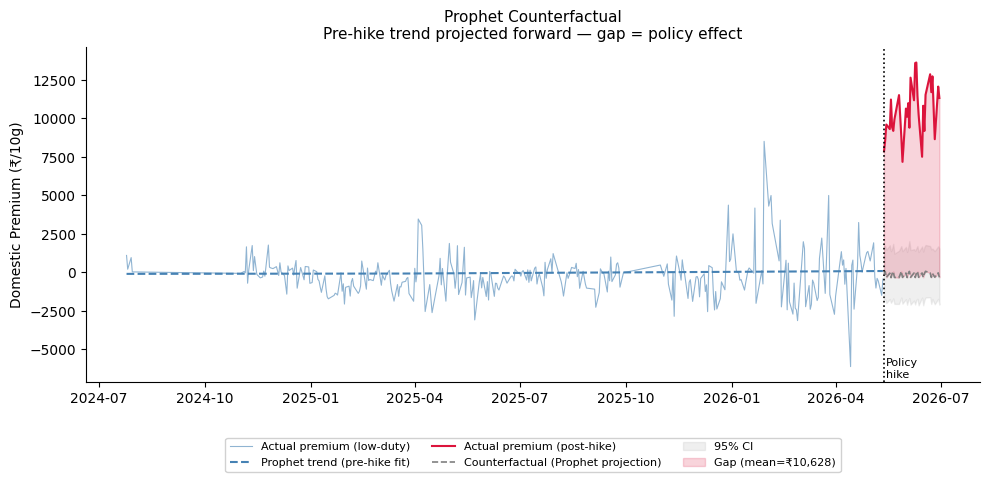

Saved: charts/fig_prophet_counterfactual.png


In [3]:
import matplotlib.pyplot as plt

# ── Prophet counterfactual chart ──────────────────────────────────────────────
pre_dates  = pdata[pre_mask]['ds']
post_dates = pdata[post_mask]['ds']
pre_fc     = forecast[pre_mask]
post_fc    = forecast[post_mask]

fig, ax = plt.subplots(figsize=(10, 5))

# Pre-hike: actual (noisy) + Prophet trend
ax.plot(pre_dates, pdata[pre_mask]['y'],
        color='steelblue', lw=0.8, alpha=0.6, label='Actual premium (low-duty)')
ax.plot(pre_fc['ds'], pre_fc['trend'],
        color='steelblue', lw=1.5, linestyle='--', label='Prophet trend (pre-hike fit)')

# Post-hike: actual + counterfactual projection
ax.plot(post_dates, post_actual,
        color='crimson', lw=1.5, label='Actual premium (post-hike)')
ax.plot(post_dates, post_pred,
        color='grey', lw=1.2, linestyle='--', label='Counterfactual (Prophet projection)')

# 95% CI on counterfactual
ax.fill_between(post_dates, post_fc['yhat_lower'], post_fc['yhat_upper'],
                alpha=0.12, color='grey', label='95% CI')

# Gap fill
ax.fill_between(post_dates, post_pred, post_actual,
                alpha=0.18, color='crimson', label=f'Gap (mean=₹{mean_gap:,.0f})')

# Policy line
ax.axvline(POLICY_DATE, color='black', lw=1.2, linestyle=':')
ax.text(POLICY_DATE + pd.Timedelta(2, 'D'), ax.get_ylim()[0] + 300,
        'Policy\nhike', fontsize=8)

ax.set_ylabel('Domestic Premium (₹/10g)', fontsize=10)
ax.set_title('Prophet Counterfactual\nPre-hike trend projected forward — gap = policy effect',
             fontsize=11)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../../charts/fig_prophet_counterfactual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: charts/fig_prophet_counterfactual.png')

In [4]:
# ── Summary ───────────────────────────────────────────────────────────────────
# Load cross-method gaps from shared cache
import json as _json
with open('../../data/its_results.json') as _f:
    _xc = _json.load(_f)
ARIMAX_GAP = _xc.get('ARIMAX_GAP', 10187.0)  # from arima.ipynb
XGB_GAP    = _xc.get('XGB_GAP',    10033.0)  # from xgboost.ipynb

all_pos = (post_actual - post_pred > 0).all()

print('=' * 55)
print('Prophet Counterfactual Summary')
print('=' * 55)
print(f'Training window   : Jul 2024 – May 12 2026 (N={pre_mask.sum()})')
print(f'Forecast horizon  : {post_mask.sum()} trading days post-hike')
print(f'Mean gap          : ₹{mean_gap:,.0f}')
print(f'All gaps positive : {all_pos}')
print()
print('Convergence across methods:')
print(f'  ITS (primary)   ₹{ITS_BETA1:,.0f}')
print(f'  ARIMAX          ₹{ARIMAX_GAP:,.0f}  ({abs(ARIMAX_GAP-ITS_BETA1)/ITS_BETA1*100:.1f}% from ITS)')
print(f'  XGBoost gap     ₹{XGB_GAP:,.0f}  ({abs(XGB_GAP-ITS_BETA1)/ITS_BETA1*100:.1f}% from ITS)')
print(f'  Prophet gap     ₹{mean_gap:,.0f}  ({abs(mean_gap-ITS_BETA1)/ITS_BETA1*100:.1f}% from ITS)')

Prophet Counterfactual Summary
Training window   : Jul 2024 – May 12 2026 (N=321)
Forecast horizon  : 31 trading days post-hike
Mean gap          : ₹10,628
All gaps positive : True

Convergence across methods:
  ITS (primary)   ₹10,124
  ARIMAX          ₹10,141  (0.2% from ITS)
  XGBoost gap     ₹10,268  (1.4% from ITS)
  Prophet gap     ₹10,628  (5.0% from ITS)
